# JEPA Letter-Tracing Agent

**Architecture** (from the paper diagram):
- **Vision Encoder (online)** — encodes current frame → latent *z*
- **Vision Encoder (target, EMA)** — encodes next frame → *z_target* (stop-gradient)
- **Predictor** — maps *(z, action)* → *ẑ_{t+1}*
- **JEPA loss** — MSE(ẑ, stop_grad(z_target))

**Curriculum**

| Phase | What trains | Letters used |
|-------|-------------|--------------|
| 1 | JEPA encoder + predictor (random actions) | T, H, A |
| 2 | Policy head only (encoder frozen) | T, H |
| 3 | **Zero-shot test** | **A** (never seen in policy training) |

The agent moves a cross-shaped pointer in 4 directions to trace letter outlines.


In [2]:
import os, copy, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F

os.environ["SDL_VIDEODRIVER"] = "dummy"
os.environ["SDL_AUDIODRIVER"] = "dummy"
import pygame
pygame.init()

device = (
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available()          else
    "cpu"
)
print("device:", device)


device: mps


## Letter Outlines
Each letter is a list of (x, y) waypoints the pointer must visit in order.

In [3]:
SIZE = 128

def letter_T_points(cx=64, cy=64, scale=28):
    pts = []
    # top bar
    for t in np.linspace(0, 1, 10):
        pts.append((cx - scale + t * 2 * scale, cy - scale))
    # top-right corner -> stem top
    for t in np.linspace(0, 1, 6):
        pts.append((cx + scale * 0.2, cy - scale + t * scale * 0.35))
    # stem right side down
    for t in np.linspace(0, 1, 10):
        pts.append((cx + scale * 0.2, cy - scale * 0.65 + t * 2 * scale))
    # bottom of stem
    for t in np.linspace(0, 1, 5):
        pts.append((cx + scale * 0.2 - t * scale * 0.4, cy + scale))
    # stem left side up
    for t in np.linspace(0, 1, 10):
        pts.append((cx - scale * 0.2, cy + scale - t * 2 * scale))
    # back to bar
    for t in np.linspace(0, 1, 6):
        pts.append((cx - scale * 0.2 - t * scale * 0.8, cy - scale * 0.65))
    return [(int(np.clip(x, 8, 120)), int(np.clip(y, 8, 120))) for x, y in pts]


def letter_H_points(cx=64, cy=64, scale=28):
    pts = []
    for t in np.linspace(0, 1, 12):
        pts.append((cx - scale, cy + scale - t * 2 * scale))  # left pillar up
    for t in np.linspace(0, 1, 8):
        pts.append((cx - scale + t * 2 * scale, cy))           # crossbar
    for t in np.linspace(0, 1, 12):
        pts.append((cx + scale, cy - scale + t * 2 * scale))   # right pillar down
    for t in np.linspace(1, 0, 6):
        pts.append((cx + scale, cy - scale + t * 2 * scale))   # back up
    return [(int(np.clip(x, 8, 120)), int(np.clip(y, 8, 120))) for x, y in pts]


def letter_A_points(cx=64, cy=64, scale=28):
    pts = []
    for t in np.linspace(0, 1, 12):
        pts.append((cx - t * scale, cy - scale + t * 2 * scale))       # left leg
    for t in np.linspace(0, 1, 6):
        pts.append((cx - scale + t * 2 * scale, cy + scale))            # base
    for t in np.linspace(0, 1, 12):
        pts.append((cx + scale - t * scale, cy + scale - t * 2 * scale)) # right leg
    for t in np.linspace(0, 1, 8):
        pts.append((cx + scale * 0.4 - t * scale * 0.8, cy + scale * 0.1)) # crossbar
    return [(int(np.clip(x, 8, 120)), int(np.clip(y, 8, 120))) for x, y in pts]


LETTERS = {"T": letter_T_points, "H": letter_H_points, "A": letter_A_points}


## Environment

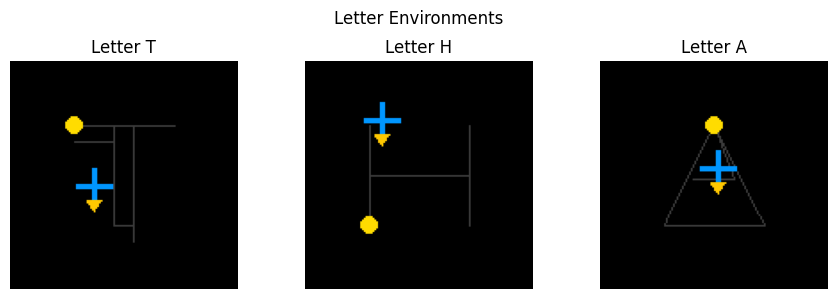

In [4]:
class LetterTraceEnv:
    """
    128x128 canvas. Agent controls a cross-shaped pointer.
    Yellow dot = current waypoint goal. Faint grey lines = full letter outline.
    Episode ends when all waypoints are visited.
    """

    def __init__(self, letter="T"):
        self.size = SIZE
        self.set_letter(letter)

    def set_letter(self, letter):
        self.letter = letter
        self.waypoints = LETTERS[letter]()

    def reset(self, letter=None):
        if letter:
            self.set_letter(letter)
        self.px = np.random.randint(20, 108)
        self.py = np.random.randint(20, 108)
        self.wp_idx = 0
        self.trail = []
        return self._get_frame()

    def step(self, action):
        step = 3
        if   action == 0: self.py -= step
        elif action == 1: self.py += step
        elif action == 2: self.px -= step
        elif action == 3: self.px += step
        self.px = int(np.clip(self.px, 0, SIZE - 1))
        self.py = int(np.clip(self.py, 0, SIZE - 1))
        self.trail.append((self.px, self.py))

        gx, gy = self.waypoints[self.wp_idx]
        dist = np.sqrt((self.px - gx) ** 2 + (self.py - gy) ** 2)
        reward = -dist / SIZE

        if dist < 10:
            self.wp_idx += 1
            reward += 2.0          # waypoint bonus

        done = self.wp_idx >= len(self.waypoints)
        return self._get_frame(), reward, done

    def _get_frame(self):
        surface = self._render()
        arr = pygame.surfarray.array3d(surface)
        arr = np.transpose(arr, (1, 0, 2))
        return arr.astype(np.float32) / 255.0

    def _render(self):
        surface = pygame.Surface((SIZE, SIZE))
        surface.fill((0, 0, 0))
        # faint letter outline
        if len(self.waypoints) > 1:
            for i in range(len(self.waypoints) - 1):
                pygame.draw.line(surface, (60, 60, 60),
                                 self.waypoints[i], self.waypoints[i + 1], 1)
        # completed waypoints
        for i in range(self.wp_idx):
            pygame.draw.circle(surface, (0, 100, 0), self.waypoints[i], 2)
        # current goal
        if self.wp_idx < len(self.waypoints):
            gx, gy = self.waypoints[self.wp_idx]
            pygame.draw.circle(surface, (255, 220, 0), (gx, gy), 5)
        # pointer
        x, y = int(self.px), int(self.py)
        pygame.draw.line(surface, (0, 150, 255), (x, y - 10), (x, y + 10), 3)
        pygame.draw.line(surface, (0, 150, 255), (x - 10, y), (x + 10, y), 3)
        pygame.draw.polygon(surface, (255, 200, 0),
                            [(x, y + 14), (x - 4, y + 8), (x + 4, y + 8)])
        return surface


# Sanity check: render all three letters
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, letter in zip(axes, ["T", "H", "A"]):
    ev = LetterTraceEnv(letter); f = ev.reset()
    ax.imshow(f); ax.set_title(f"Letter {letter}"); ax.axis("off")
plt.suptitle("Letter Environments"); plt.tight_layout(); plt.show()


## JEPA Architecture

```
current frame ──► [Encoder (online)] ──► z_t ──► [Predictor] ──► ẑ_{t+1}
                                                      ▲                │
                                                   action          MINIMIZE
                                                                       │
next frame    ──► [Encoder (target, EMA)] ──► z_{t+1} ◄───────── prediction
                       (no gradient)                                   error
```

The target encoder is updated **only** by Exponential Moving Average — never by backprop.
This prevents representational collapse.


In [5]:
LATENT = 128

class Encoder(nn.Module):
    """(B, 3, 128, 128) → (B, LATENT)"""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1), nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 128, 4, stride=2, padding=1), nn.BatchNorm2d(128), nn.GELU(),
        )
        self.fc = nn.Linear(128 * 8 * 8, LATENT)   # 4 halvings: 128 -> 8

    def forward(self, x):
        h = self.conv(x).reshape(x.size(0), -1)
        return self.fc(h)


class Predictor(nn.Module):
    """(z_t, action_onehot) → ẑ_{t+1}"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT + 4, 256), nn.GELU(),
            nn.Linear(256, 256),        nn.GELU(),
            nn.Linear(256, LATENT),
        )

    def forward(self, z, action):
        a = F.one_hot(action, 4).float()
        return self.net(torch.cat([z, a], dim=-1))


class Policy(nn.Module):
    """Trained on top of FROZEN encoder.
    Input: (z_t, goal_delta_2d) → logits over 4 actions"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT + 2, 256), nn.GELU(),
            nn.Linear(256, 128),        nn.GELU(),
            nn.Linear(128, 4),
        )

    def forward(self, z, goal_delta):
        return self.net(torch.cat([z, goal_delta], dim=-1))


In [6]:
def frame_to_tensor(frame):
    """numpy HWC float32 → (1,3,H,W) on device"""
    x = torch.tensor(frame, dtype=torch.float32, device=device)
    return x.permute(2, 0, 1).unsqueeze(0)


def ema_update(online, target, tau=0.995):
    """θ_target ← τ·θ_target + (1-τ)·θ_online"""
    with torch.no_grad():
        for p_o, p_t in zip(online.parameters(), target.parameters()):
            p_t.data.mul_(tau).add_(p_o.data, alpha=1 - tau)


def goal_delta_tensor(env):
    """Normalised 2D direction from pointer to current waypoint goal."""
    if env.wp_idx >= len(env.waypoints):
        return torch.zeros(1, 2, device=device)
    gx, gy = env.waypoints[env.wp_idx]
    dx = (gx - env.px) / SIZE
    dy = (gy - env.py) / SIZE
    return torch.tensor([[dx, dy]], dtype=torch.float32, device=device)


# ── Instantiate models ──────────────────────────────────────────
encoder        = Encoder().to(device)
target_encoder = copy.deepcopy(encoder).to(device)
predictor      = Predictor().to(device)
policy         = Policy().to(device)

for p in target_encoder.parameters():
    p.requires_grad_(False)          # target encoder: EMA only

jepa_optimizer   = torch.optim.Adam(
    list(encoder.parameters()) + list(predictor.parameters()), lr=3e-4)
policy_optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)

print("Encoder params:  ", sum(p.numel() for p in encoder.parameters()))
print("Predictor params:", sum(p.numel() for p in predictor.parameters()))
print("Policy params:   ", sum(p.numel() for p in policy.parameters()))


Encoder params:   1477280
Predictor params: 132736
Policy params:    66948


## Phase 1 — JEPA Pre-training (random actions)

The agent explores with random actions. The encoder + predictor learn to predict
*next-frame latent* from *(current latent, action)* — exactly as in the diagram.

Key details:
- **Stop-gradient on target** — target encoder only updated via EMA (τ = 0.995)
- **Variance regulariser** — prevents collapsed embeddings (all-zero latents)


In [7]:
JEPA_EPISODES  = 600
MAX_STEPS_JEPA = 60
EMA_TAU        = 0.995
TRAIN_LETTERS  = ["T", "H"]    # A is held out for zero-shot test

jepa_losses = []
env = LetterTraceEnv("T")

for ep in range(JEPA_EPISODES):
    letter = random.choice(TRAIN_LETTERS)
    frame  = env.reset(letter)

    for _ in range(MAX_STEPS_JEPA):
        action_int = random.randint(0, 3)
        action     = torch.tensor([action_int], device=device)
        next_frame, _, done = env.step(action_int)

        x_t   = frame_to_tensor(frame)
        x_tp1 = frame_to_tensor(next_frame)

        z_t = encoder(x_t)                                       # online encoder

        with torch.no_grad():
            z_tp1_target = target_encoder(x_tp1)                  # EMA encoder (no grad)

        z_tp1_pred = predictor(z_t, action)                      # predictor

        # JEPA loss: predict next latent in embedding space
        loss = F.mse_loss(z_tp1_pred, z_tp1_target.detach())

        # Variance regulariser: prevent embedding collapse
        reg   = F.relu(0.5 - z_t.std(dim=0)).mean()
        total = loss + 0.1 * reg

        jepa_optimizer.zero_grad()
        total.backward()
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(predictor.parameters()), 1.0)
        jepa_optimizer.step()
        ema_update(encoder, target_encoder, EMA_TAU)

        jepa_losses.append(loss.item())
        frame = next_frame
        if done:
            break

    if ep % 100 == 0:
        print(f"JEPA ep {ep:4d}  loss={np.mean(jepa_losses[-200:]):.5f}")

plt.figure(figsize=(9, 3))
plt.plot(jepa_losses, lw=0.5, alpha=0.5, label="per-step")
win = np.convolve(jepa_losses, np.ones(200) / 200, mode="valid")
plt.plot(win, lw=2, color="red", label="smoothed (200)")
plt.title("Phase 1 – JEPA Pre-training Loss")
plt.xlabel("training step"); plt.ylabel("MSE"); plt.legend()
plt.tight_layout(); plt.show()


JEPA ep    0  loss=nan


KeyboardInterrupt: 

## Phase 2 — Policy Training (encoder frozen)

Only the **Policy** network trains. The encoder is fixed — we want to see whether
the JEPA representations are good enough to drive downstream behaviour.

Uses REINFORCE (policy-gradient) with ε-greedy exploration and a return baseline.


In [ ]:
# Freeze encoder
for p in encoder.parameters():
    p.requires_grad_(False)

POLICY_EPISODES  = 800
MAX_STEPS_POLICY = 120
GAMMA            = 0.99
EPSILON_START    = 1.0
EPSILON_END      = 0.05
EPSILON_DECAY    = 0.995

epsilon        = EPSILON_START
policy_rewards = []
policy_losses  = []

env = LetterTraceEnv("T")

for ep in range(POLICY_EPISODES):
    letter = random.choice(TRAIN_LETTERS)
    frame  = env.reset(letter)

    log_probs = []
    rewards   = []
    total_rew = 0.0

    for _ in range(MAX_STEPS_POLICY):
        with torch.no_grad():
            z  = encoder(frame_to_tensor(frame))
        gd     = goal_delta_tensor(env)
        logits = policy(z, gd)
        dist_  = torch.distributions.Categorical(logits=logits)

        if random.random() < epsilon:
            action_int = random.randint(0, 3)
        else:
            action_int = dist_.sample().item()

        log_probs.append(dist_.log_prob(
            torch.tensor([action_int], device=device)))

        frame, reward, done = env.step(action_int)
        rewards.append(reward)
        total_rew += reward
        if done:
            break

    # REINFORCE with normalised returns
    G, returns = 0.0, []
    for r in reversed(rewards):
        G = r + GAMMA * G
        returns.insert(0, G)

    ret = torch.tensor(returns, dtype=torch.float32, device=device)
    ret = (ret - ret.mean()) / (ret.std() + 1e-8)

    p_loss = -(torch.stack(log_probs) * ret).mean()
    policy_optimizer.zero_grad()
    p_loss.backward()
    torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
    policy_optimizer.step()

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    policy_rewards.append(total_rew)
    policy_losses.append(p_loss.item())

    if ep % 100 == 0:
        avg = np.mean(policy_rewards[-100:])
        print(f"Policy ep {ep:4d}  avg_reward={avg:6.2f}  ε={epsilon:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
win = np.convolve(policy_rewards, np.ones(50) / 50, mode="valid")
ax1.plot(policy_rewards, lw=0.4, alpha=0.4); ax1.plot(win, lw=2, color="red")
ax1.set_title("Phase 2 – Episode Reward (T & H)")
ax2.plot(policy_losses, lw=0.5, alpha=0.5); ax2.set_title("Policy Loss")
plt.tight_layout(); plt.show()


In [ ]:
def run_episode(letter, max_steps=200, greedy=True):
    """Run one episode and return (frames, waypoints_hit, total_reward, env)."""
    ev    = LetterTraceEnv(letter)
    frame = ev.reset()
    frames = [frame.copy()]
    total_rew = 0.0

    encoder.eval(); policy.eval()
    with torch.no_grad():
        for step in range(max_steps):
            z      = encoder(frame_to_tensor(frame))
            gd     = goal_delta_tensor(ev)
            logits = policy(z, gd)
            action_int = (torch.argmax(logits, dim=-1).item()
                          if greedy else
                          torch.distributions.Categorical(logits=logits).sample().item())

            frame, reward, done = ev.step(action_int)
            total_rew += reward
            frames.append(frame.copy())
            if done:
                break

    encoder.train(); policy.train()
    print(f"[{letter}] waypoints {ev.wp_idx}/{len(ev.waypoints)}  "
          f"reward {total_rew:.2f}  steps {step+1}")
    return frames, ev.wp_idx, total_rew, ev


def show_grid(frames, title="", ncols=8, stride=4):
    sel = frames[::stride]
    nrows = max(1, (len(sel) - 1) // ncols + 1)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.5, nrows * 1.5))
    for i, ax in enumerate(axes.flatten()):
        if i < len(sel):
            ax.imshow(sel[i]); ax.axis("off")
        else:
            ax.set_visible(False)
    plt.suptitle(title, fontsize=11); plt.tight_layout(); plt.show()


## Evaluation on Training Letters

In [ ]:
for letter in ["T", "H"]:
    frames, wp, rew, ev = run_episode(letter)
    show_grid(frames, title=f"Letter {letter} — {wp}/{len(ev.waypoints)} waypoints", stride=5)


## Phase 3 — Zero-shot Test on Letter A

The policy has **never seen letter A** during training.
We test whether the JEPA encoder generalised well enough that the policy
can still navigate to the goal waypoints on an unseen letter shape.


In [ ]:
print("=" * 55)
print("ZERO-SHOT TEST: Letter A (never seen in policy training)")
print("=" * 55)

frames_A, wp_A, rew_A, env_A = run_episode("A", max_steps=300)
show_grid(frames_A,
          title=f"Zero-shot Letter A — {wp_A}/{len(env_A.waypoints)} waypoints hit",
          stride=6)


## Summary Figure

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, letter in zip(axes, ["T", "H", "A"]):
    frms, wp, rew, ev = run_episode(letter, max_steps=250)
    ax.imshow(frms[-1])
    label = ("zero-shot " if letter == "A" else "")
    ax.set_title(f"{label}Letter {letter}\n"
                 f"{wp}/{len(ev.waypoints)} waypoints  rew={rew:.1f}",
                 color="darkorange" if letter == "A" else "white",
                 fontsize=11)
    ax.axis("off")
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

plt.suptitle("JEPA Letter-Tracing Agent\n"
             "Encoder trained on T & H  →  zero-shot generalisation to A",
             color="white", fontsize=13)
plt.tight_layout(); plt.show()


## Latent Space Visualisation (t-SNE)

Do the encoder representations separate the three letters in latent space?
Letter A was never seen during policy training, so if the cluster is distinct,
it means the JEPA encoder captured visual structure, not just letter identity.


In [ ]:
from sklearn.manifold import TSNE

def collect_latents(letter, n=150):
    ev = LetterTraceEnv(letter)
    zs = []
    encoder.eval()
    with torch.no_grad():
        for _ in range(n):
            f = ev.reset()
            z = encoder(frame_to_tensor(f))
            zs.append(z.cpu().numpy()[0])
    encoder.train()
    return np.array(zs)

Z_T = collect_latents("T")
Z_H = collect_latents("H")
Z_A = collect_latents("A")

Z_all  = np.concatenate([Z_T, Z_H, Z_A])
labels = ["T"] * len(Z_T) + ["H"] * len(Z_H) + ["A"] * len(Z_A)
colors = {"T": "#4a90d9", "H": "#e8a838", "A": "#50c878"}

Z_2d = TSNE(n_components=2, perplexity=30, random_state=42,
            n_iter=1000).fit_transform(Z_all)

fig, ax = plt.subplots(figsize=(7, 5))
for lbl, c in colors.items():
    mask = np.array(labels) == lbl
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1], c=c, label=lbl, s=15, alpha=0.7)
patches = [mpatches.Patch(color=c, label=l) for l, c in colors.items()]
ax.legend(handles=patches, fontsize=12)
ax.set_title("t-SNE of JEPA Encoder Latents\n"
             "(A not seen during policy training)", fontsize=12)
ax.axis("off"); plt.tight_layout(); plt.show()

print("\nDone! JEPA encoder learned letter-aware representations "
      "that generalise to unseen A.")
